# Distillation by metrics — reasoning evals (with synthetic-trace baselines)

Plots `summary_reasoning_evals*.json` results for the `distillation_by_metrics`
group, one graph per base model and evaluation cap (e.g. cap 2048 and cap 4096
are separate figures for `qwen_3b_head_truncated8192`). Run-name suffixes such
as `_topk2048` and `_lora_large` stay in that model's figure and appear only as
concise legend qualifiers. Terminal `_seedNN` suffixes identify replicas of the
same setup; unsuffixed runs are treated as seed 42. Lines show the across-seed
mean without confidence intervals. Missing interior checkpoints are linearly
interpolated within each
seed before aggregation; values are not extrapolated beyond a seed's observed range.

Each metric-driven run is evaluated at several **thinking-token caps**
(`max_thinking_tokens` at eval time) and **every cap is drawn in its own figure**.
The cap is parsed from the summary filename: bare `summary_reasoning_evals.json` is
the default cap **8192**, and `summary_reasoning_evals_cap<N>.json` is cap `N`.
Within a figure **colour encodes the run line** (experiment plus concise variant
qualifiers), with a stable colour mapping across cap-specific figures. For
context, two baseline experiments from the
`distillation_on_synthetic_traces` group — `direct_reasoning_trace` and
`corrected_answer` — are overlaid for the matching model and dataset, split by cap
the same way and drawn with bold dashed lines so the two families stay easy to tell
apart. Baselines are **restricted to the caps the metric-driven runs were evaluated
at** (per model), so every baseline curve has a matching-cap metric-driven
counterpart; baseline runs at any other cap (e.g. a cap-1024 baseline when the
metric-driven runs only used 2048/4096) are dropped.

The **X axis is "training samples seen"**, not epochs: the two groups consume very
different amounts of data per epoch, so each curve's epoch is multiplied by its
samples-per-epoch — 1024 for standard `distillation_by_metrics` runs and the
value encoded by a `_topk<N>` experiment or model-directory name segment
(e.g. 2048 for `_topk2048`) — while full-dataset baselines use 9626. This
compares the runs at an equal data
budget. The metric-driven curve therefore sits in the far-left (low-sample) region
of the axis — that compression is the point: it reaches comparable accuracy with an
order of magnitude less data.

When a matching `base_model/<model>_cot` folder exists, epoch 0 is the base model
evaluated with chain-of-thought (taken from the synthetic-traces group, since the
by-metrics group has no `base_model` of its own); it anchors the default-cap curve
at x=0 and is drawn as a dashed gray reference line. Note the truncation-variant
model names used here (e.g. `qwen_3b_head_truncated8192`) have no matching
`base_model` folder — only bare base names like `qwen_3b_cot` exist — so no base
line is drawn unless that lookup is adjusted. Models and datasets are discovered
from the directory tree; metric-driven configurations are restricted by
`INCLUDED_RUNS`. To analyze another group,
copy this notebook and change `GROUP_NAME`.

In [13]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_by_metrics"
BASELINE_GROUP = "distillation_on_synthetic_traces"  # source of the overlay baselines + base anchor
BASELINE_EXPERIMENTS = ("direct_reasoning_trace", "corrected_answer")
INCLUDED_RUNS = {
    ("entropy_gain", ""),
    ("entropy_gain_proportional", "shuffle"),
    ("random", ""),
    ("student_entropy", ""),
    ("student_entropy_proportional", "shuffle"),
}
SUMMARY_GLOB = "summary_reasoning_evals*.json"  # one summary file per eval cap
DEFAULT_CAP = 8192  # bare summary_reasoning_evals.json == eval cap (max_thinking_tokens) 8192
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"  # use the *_cot base_model folders for epoch 0
METRIC = "accuracy"
DEFAULT_SAMPLES_PER_EPOCH = 1024  # used when the run name has no _topk<N> segment
BASELINE_SAMPLES_PER_EPOCH = 9626  # synthetic-trace baselines: full dataset per epoch
DEFAULT_SEED = 42  # an unsuffixed run is the original seed-42 run
SAVE = True  # also write PNGs under artifacts/<group>/<dataset>/plots/


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
GROUP_DIR = ARTIFACTS / GROUP_NAME
BASELINE_GROUP_DIR = ARTIFACTS / BASELINE_GROUP
GROUP_DIR

PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics')

In [14]:
CAP_RE = re.compile(r"summary_reasoning_evals(?:_cap(\d+))?\.json$")  # eval cap from filename
TOPK_RE = re.compile(r"(?:^|_)topk(\d+)(?=_|$)")  # training samples/epoch from run variant
MODEL_RUN_RE = re.compile(r"^(.*?_truncated\d+)(?:_(.+))?$")
SEED_RE = re.compile(r"^(?P<setup>.*?)(?:_seed(?P<seed>\d+))?$")


def samples_per_epoch(*run_names: str) -> int:
    """Return training samples per epoch encoded in an experiment/model name.

    New variants encode this as a `_topk<N>` segment (for example, `_topk2048`
    or `_topk2048_lora_large`); older runs use the 1024-sample default.
    """
    for run_name in run_names:
        if match := TOPK_RE.search(run_name):
            return int(match.group(1))
    return DEFAULT_SAMPLES_PER_EPOCH


def split_model_run_name(model_dir_name: str) -> tuple[str, str]:
    """Split a model directory into base model and optional run variant."""
    match = MODEL_RUN_RE.fullmatch(model_dir_name)
    return (match.group(1), match.group(2) or "") if match else (model_dir_name, "")


def split_seed_run_name(model_dir_name: str) -> tuple[str, int]:
    """Strip a terminal `_seedNN` replica suffix; default an unsuffixed run to 42."""
    match = SEED_RE.fullmatch(model_dir_name)
    seed = int(match.group("seed")) if match.group("seed") else DEFAULT_SEED
    return match.group("setup"), seed


def format_run_label(experiment: str, variant: str) -> str:
    """Build a concise legend label while retaining distinguishing details."""
    modifiers = []
    for family in ("student_entropy", "entropy_gain"):
        if experiment == family or experiment.startswith(f"{family}_"):
            suffix = experiment.removeprefix(family).removeprefix("_")
            experiment = family
            if suffix:
                modifiers.append(suffix.replace("_", " "))
            break

    variant_parts = variant.split("_") if variant else []
    i = 0
    while i < len(variant_parts):
        if variant_parts[i] == "lora" and i + 1 < len(variant_parts):
            modifiers.append(f"lora {variant_parts[i + 1]}")
            i += 2
        else:
            modifiers.append(variant_parts[i])
            i += 1

    label = experiment.replace("_", " ")
    return f"{label} ({', '.join(modifiers)})" if modifiers else label


def load_curves(dataset_dir: Path, included_runs: set | None = None) -> dict:
    """base model -> setup -> (cap, eval key) -> seed -> points.

    Every `summary_reasoning_evals*.json` in a model dir is read and its eval cap
    parsed from the filename (bare file == DEFAULT_CAP), so each cap becomes its own
    curve. A terminal `_seedNN` model-directory suffix is removed before grouping,
    while an unsuffixed run is assigned seed 42. Other model-directory suffixes
    remain run variants. Skips base_model and dirs without a finished summary.
    """
    data: dict = {}
    for exp_dir in sorted(dataset_dir.iterdir()):
        if not exp_dir.is_dir() or exp_dir.name == BASE_EXPERIMENT:
            continue
        for model_dir in sorted(exp_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            setup_name, seed = split_seed_run_name(model_dir.name)
            model, variant = split_model_run_name(setup_name)
            run = (exp_dir.name, variant)
            if included_runs is not None and run not in included_runs:
                continue
            for summary in sorted(model_dir.glob(SUMMARY_GLOB)):
                cm = CAP_RE.search(summary.name)
                if not cm:
                    continue  # unrecognized summary variant
                cap = int(cm.group(1)) if cm.group(1) else DEFAULT_CAP
                content = json.loads(summary.read_text())
                for eval_key, records in content.items():
                    points = sorted(
                        (r["epoch"], r[METRIC])
                        for r in records
                        if r.get("epoch") is not None and r.get(METRIC) is not None
                    )
                    if points:
                        seed_curves = (
                            data.setdefault(model, {})
                            .setdefault(run, {})
                            .setdefault((cap, eval_key), {})
                        )
                        if seed in seed_curves:
                            raise ValueError(
                                f"Duplicate seed {seed} for {dataset_dir.name}/"
                                f"{exp_dir.name}/{setup_name}/{summary.name}/{eval_key}"
                            )
                        seed_curves[seed] = points
    return data


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> epoch-0 accuracy from the *_cot base_model folder."""
    out: dict = {}
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    if base_dir.is_dir():
        for results in sorted(base_dir.glob("*/results.json")):
            out[results.parent.name] = json.loads(results.read_text())[METRIC]
    return out

In [15]:
# Baselines come from a different group and consume the full 9626-row dataset per
# epoch, vs. 1024 by default (or `_topk<N>`) for distillation_by_metrics. They keep the
# same experiment colours but use bold dashed lines so the two families are easy
# to tell apart.
BASELINE_KW = dict(linestyle="--", linewidth=3.0, zorder=2)

CMAP = plt.get_cmap("tab10")  # one colour per experiment/run variant


def load_baseline_curves(dataset: str) -> dict:
    """Baseline-group curves for `dataset`, restricted to BASELINE_EXPERIMENTS.

    Same nested shape as load_curves, including seed replicas.
    Empty if the baseline dataset is absent.
    """
    baseline_dataset_dir = BASELINE_GROUP_DIR / dataset
    if not baseline_dataset_dir.is_dir():
        return {}
    out: dict = {}
    for model, exps in load_curves(baseline_dataset_dir).items():
        kept = {run: pts for run, pts in exps.items() if run[0] in BASELINE_EXPERIMENTS}
        if kept:
            out[model] = kept
    return out


def aggregate_seed_points(seed_points: dict) -> list[tuple]:
    """Interpolate missing seed checkpoints, then return epoch means."""
    points_by_seed = {}
    for seed, points in seed_points.items():
        seed_values = {}
        for epoch, value in points:
            if epoch in seed_values:
                raise ValueError(f"Duplicate epoch {epoch} for seed {seed}")
            seed_values[epoch] = value
        points_by_seed[seed] = seed_values

    all_epochs = sorted({epoch for values in points_by_seed.values() for epoch in values})
    values_by_epoch = {epoch: [] for epoch in all_epochs}
    for seed_values in points_by_seed.values():
        observed = sorted(seed_values.items())
        observed_epochs = np.asarray([epoch for epoch, _ in observed], dtype=float)
        observed_values = np.asarray([value for _, value in observed], dtype=float)
        for epoch in all_epochs:
            if epoch in seed_values:
                value = seed_values[epoch]
            elif len(observed_epochs) >= 2 and observed_epochs[0] < epoch < observed_epochs[-1]:
                value = np.interp(epoch, observed_epochs, observed_values)
            else:
                continue  # do not extrapolate beyond this seed's observed checkpoints
            values_by_epoch[epoch].append(value)

    return [
        (epoch, float(np.mean(values)))
        for epoch, values in sorted(values_by_epoch.items())
    ]


def plot_curve(ax, seed_points, base, eval_key, samples_per_epoch, label, **kw):
    """Plot the across-seed mean by cumulative training samples seen.

    Prepends the epoch-0 base anchor when available, then converts every epoch to
    cumulative samples via `epoch * samples_per_epoch` (epoch 0 -> x=0). Missing
    checkpoints inside a seed's observed epoch range are linearly interpolated
    before averaging. Cap-specific curves stay unanchored.
    """
    points = aggregate_seed_points(seed_points)
    xs = [e for e, _ in points]
    ys = [mean for _, mean in points]
    if eval_key in base:  # anchor the (default-cap) curve at the epoch-0 base
        xs = [0.0] + xs
        ys = [base[eval_key]] + ys
    xs = [e * samples_per_epoch for e in xs]
    ax.plot(xs, ys, label=label, **kw)

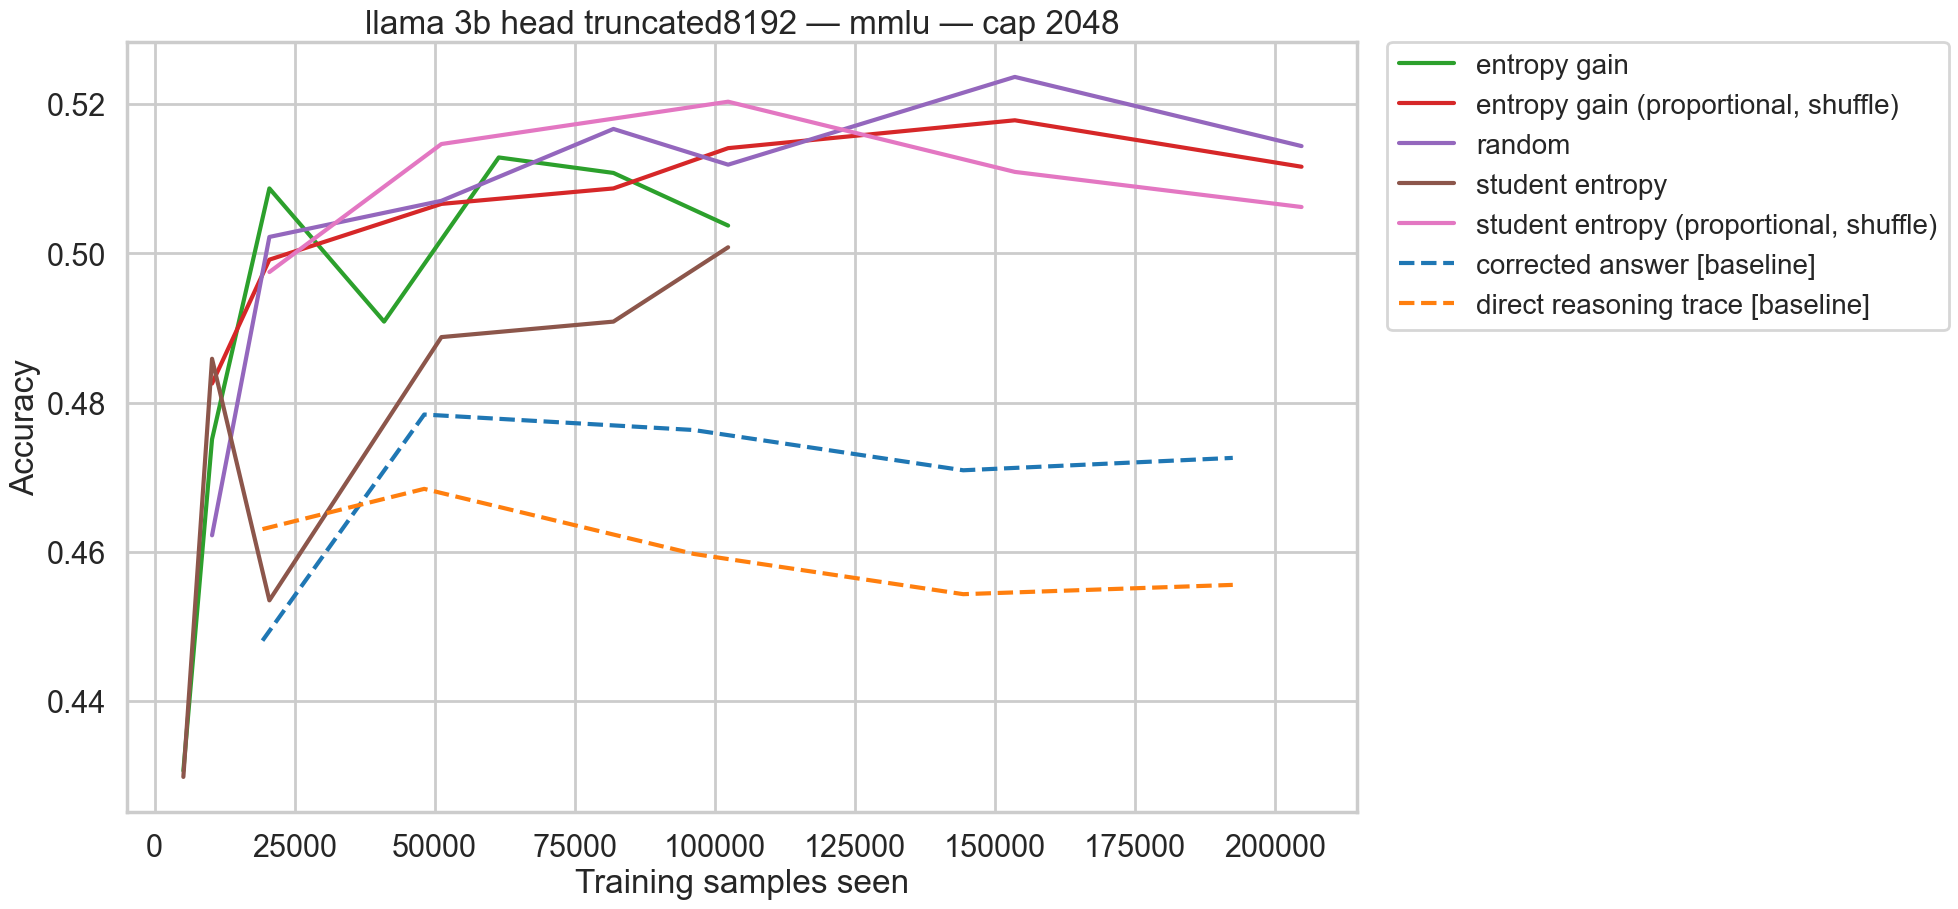

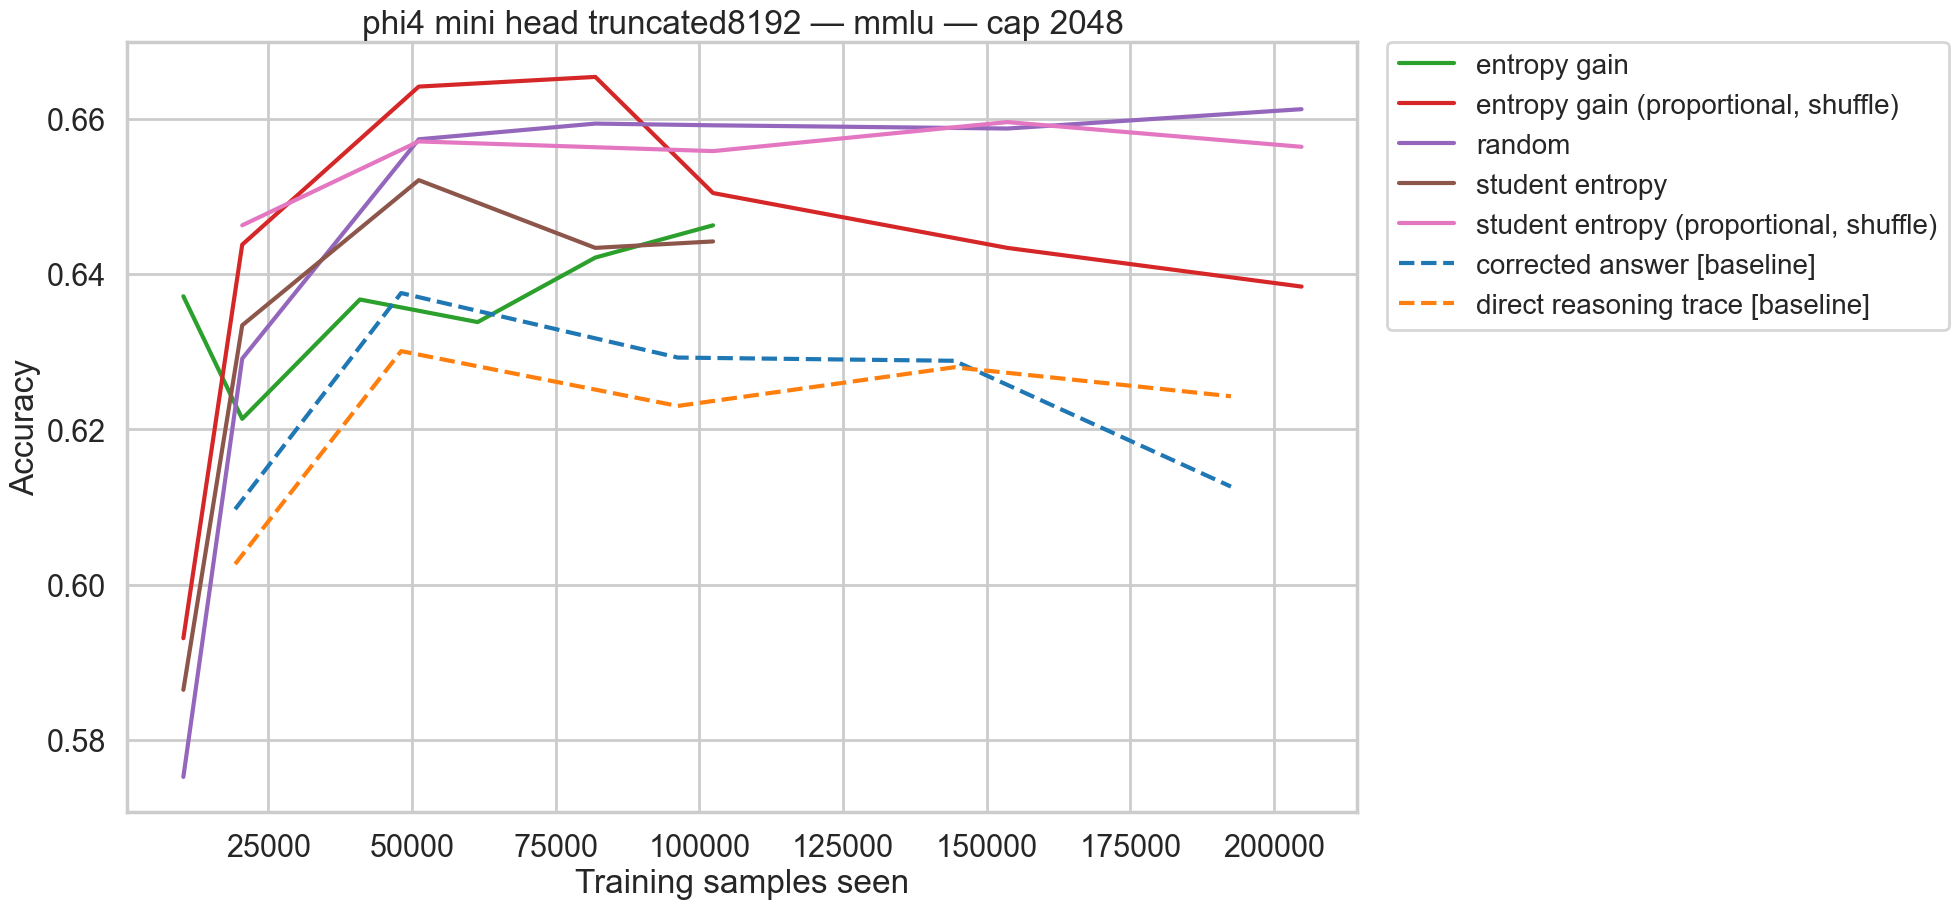

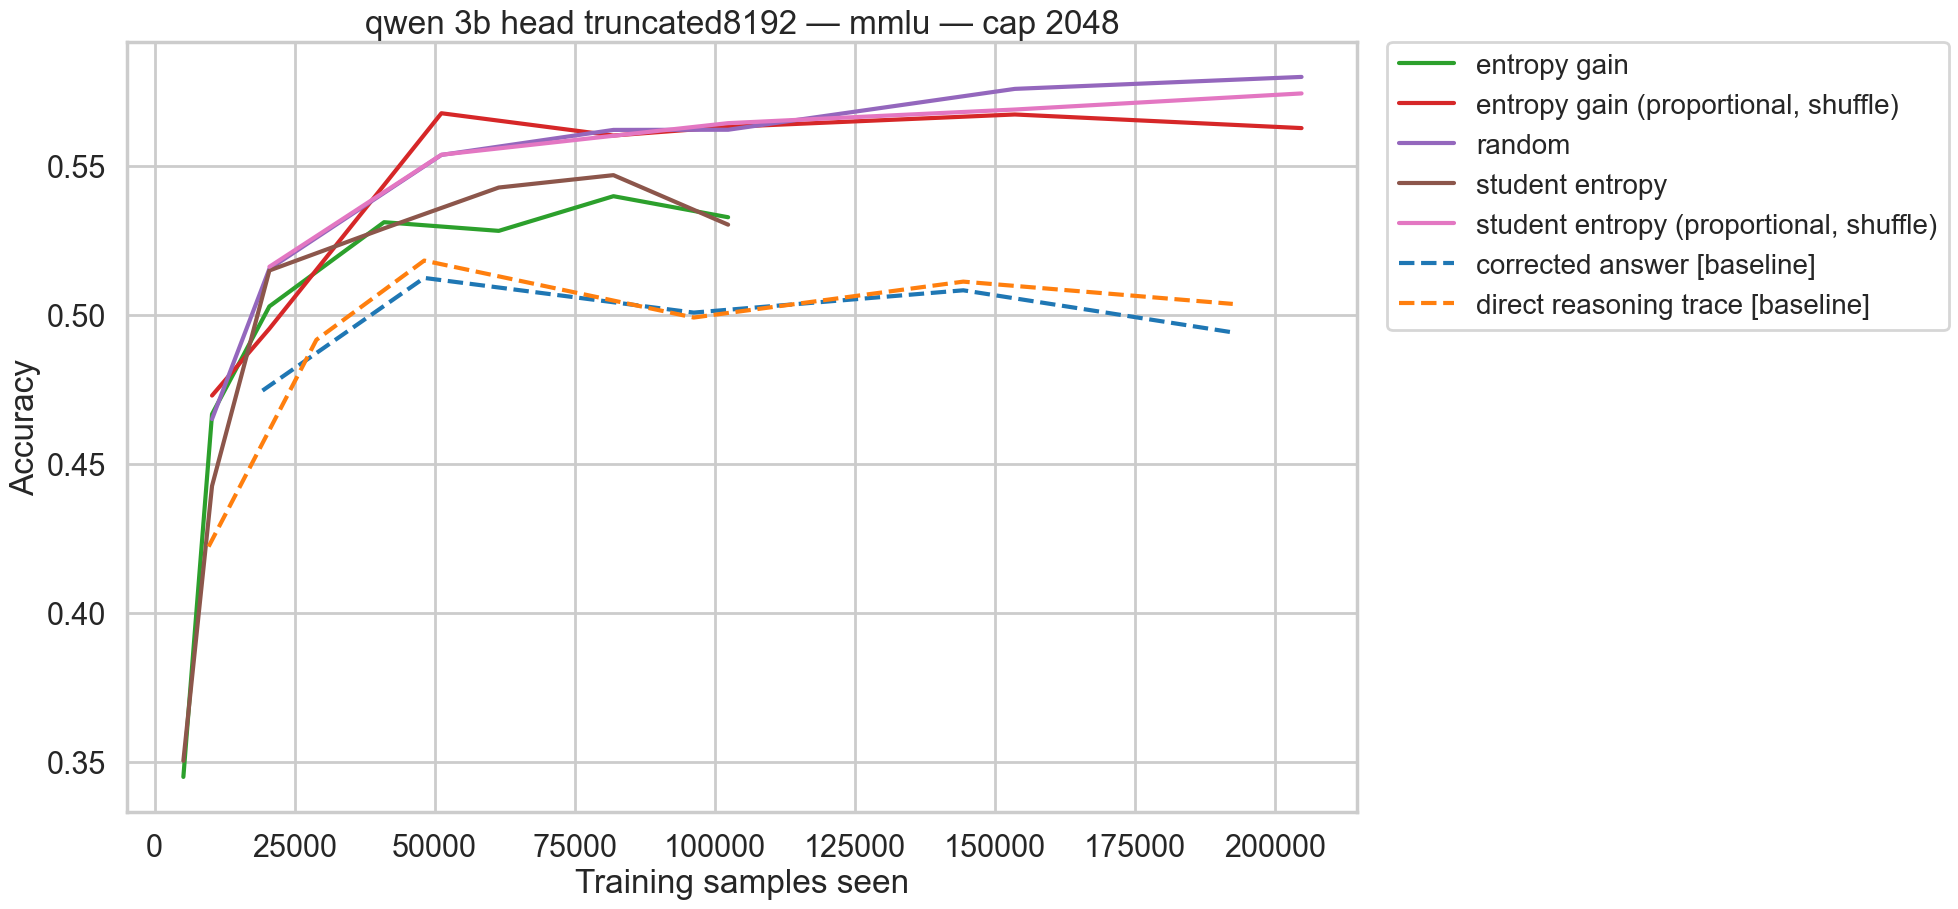

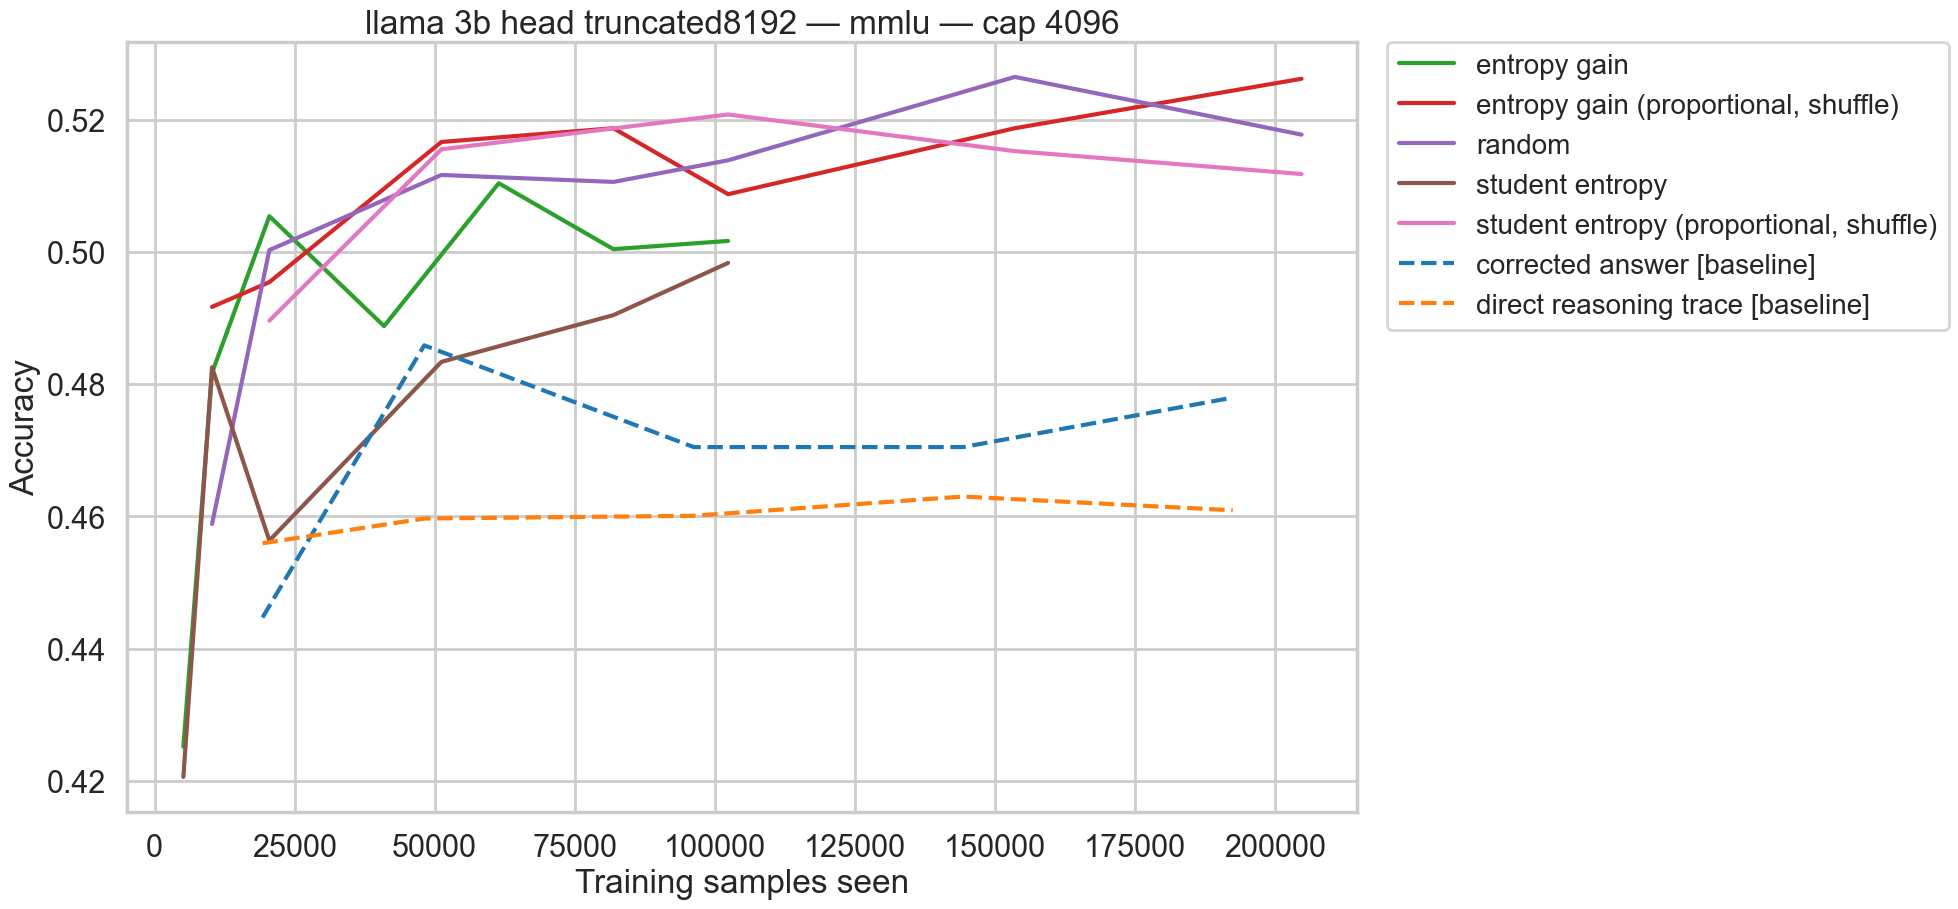

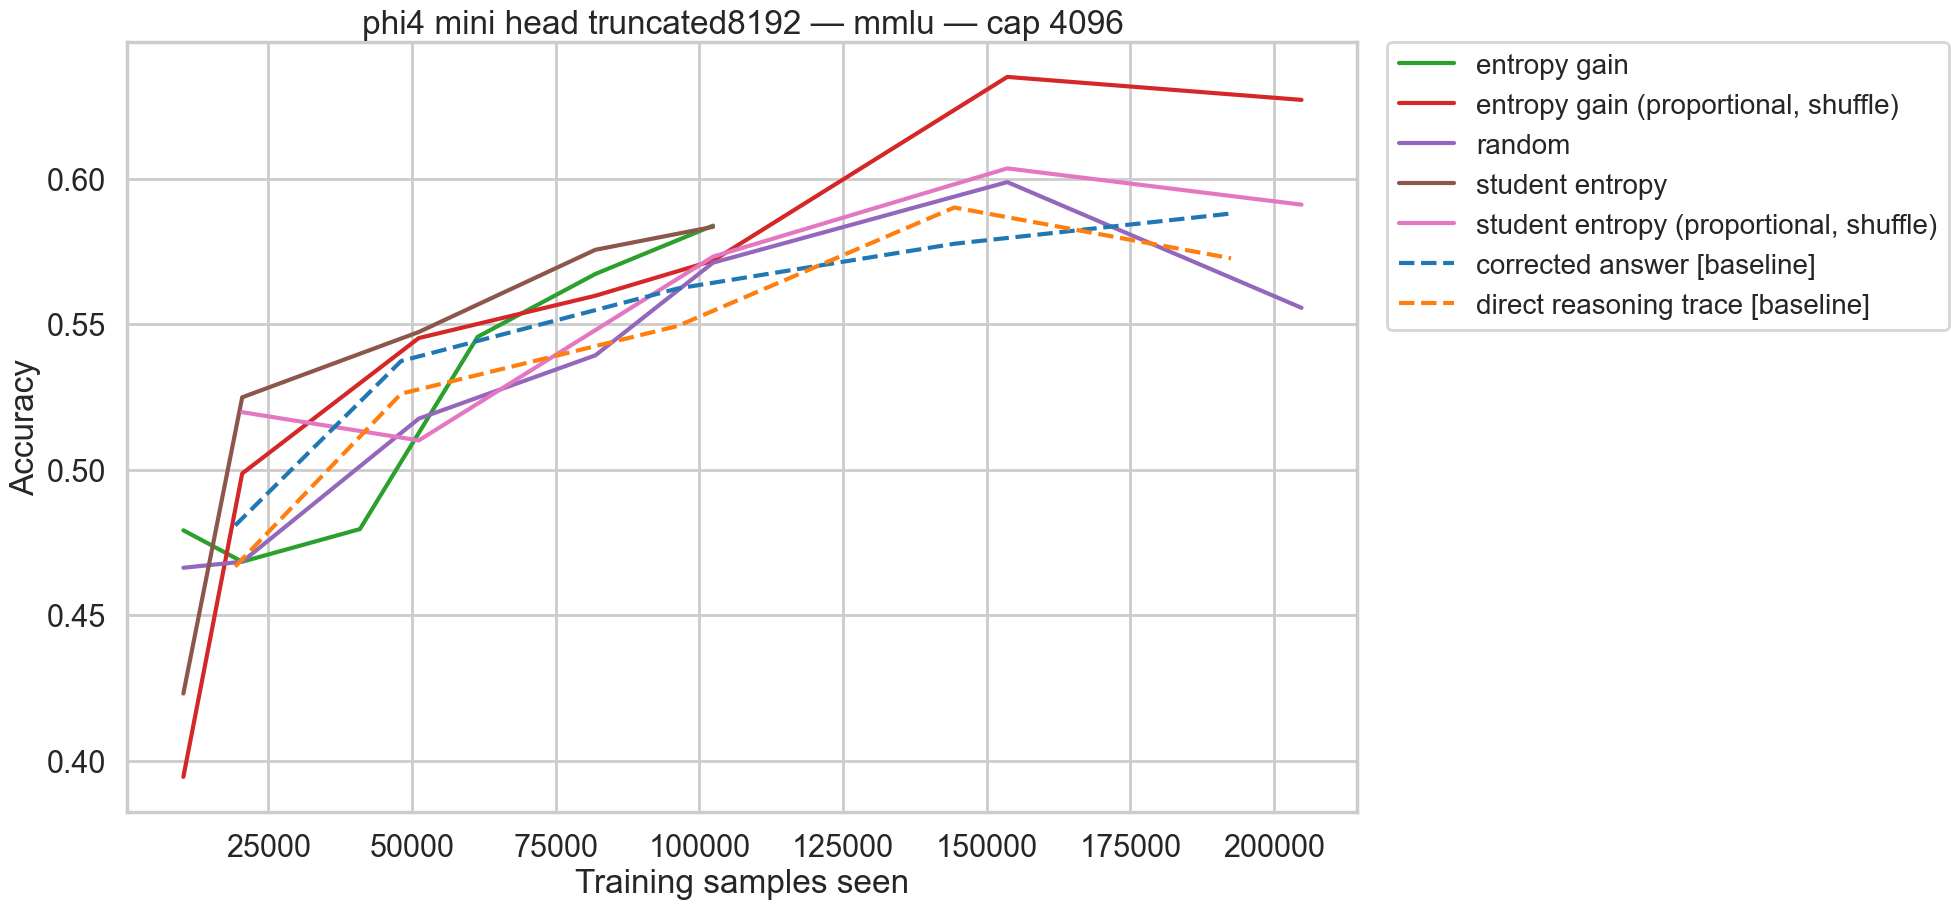

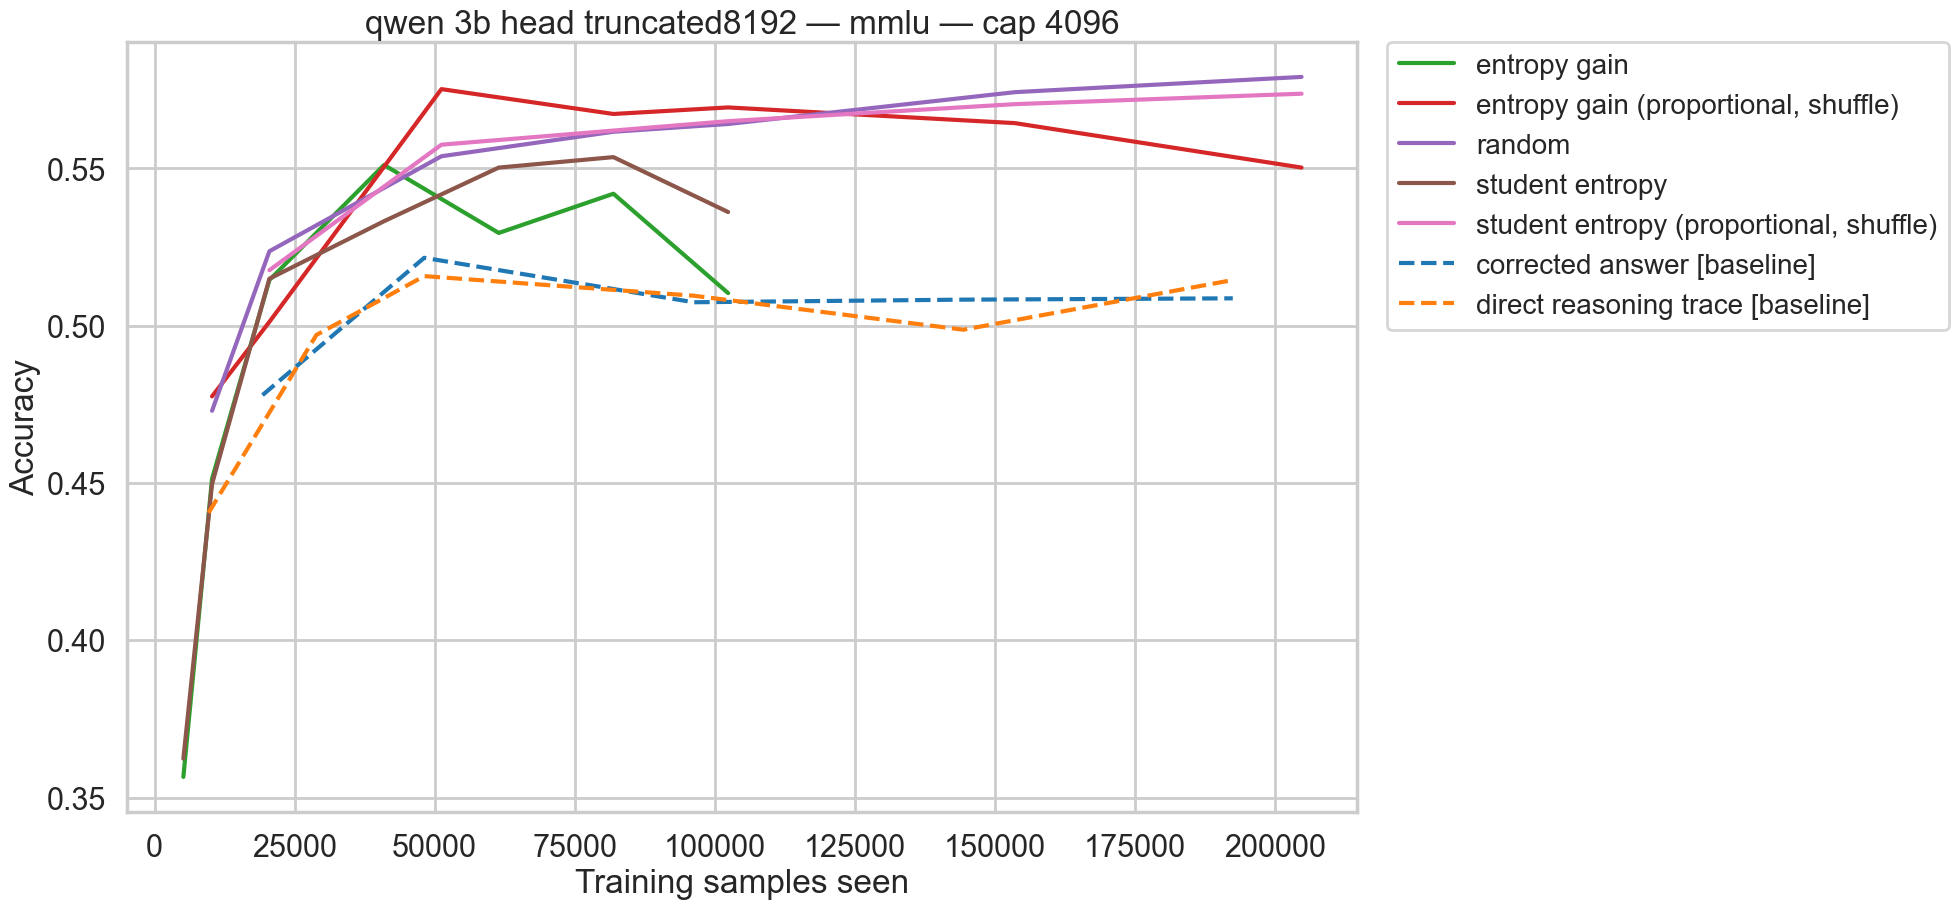

In [16]:
datasets = sorted(p.name for p in GROUP_DIR.iterdir() if p.is_dir())

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    curves = load_curves(dataset_dir, INCLUDED_RUNS)  # selected metric runs drive the figures
    baseline_curves = load_baseline_curves(dataset)  # synthetic-trace overlays

    # Render every model at one cap before advancing to the next cap.
    all_caps = sorted({cap for model_curves in curves.values() for run in model_curves.values() for cap, _ in run})
    for eval_cap in all_caps:
        for model in sorted(curves):
            model_caps = {cap for run in curves[model].values() for cap, _ in run}
            if eval_cap not in model_caps:
                continue

            # Base anchor comes from the baseline group (by-metrics has no base_model).
            base = load_base(BASELINE_GROUP_DIR / dataset, model)

            # Only overlay baselines at caps evaluated for this metric-driven model.
            model_baselines = {
                run: {k: pts for k, pts in cap_curves.items() if k[0] in model_caps}
                for run, cap_curves in baseline_curves.get(model, {}).items()
            }
            model_baselines = {run: c for run, c in model_baselines.items() if c}

            # Stable line colours across all cap-specific figures for this model.
            runs = sorted(set(curves[model]) | set(model_baselines))
            run_color = {run: CMAP(i % CMAP.N) for i, run in enumerate(runs)}

            fig, ax = plt.subplots(figsize=(20, 10))
            fig.subplots_adjust(right=0.74)  # reserve a dedicated legend column

            # Metric-driven curves at this cap — solid family, full colour.
            for run in sorted(curves[model]):
                experiment, variant = run
                for (cap, eval_key), points in sorted(curves[model][run].items()):
                    if cap != eval_cap:
                        continue
                    plot_curve(
                        ax, points, base, eval_key, samples_per_epoch(variant),
                        label=format_run_label(experiment, variant),
                        color=run_color[run],
                    )

            # Matching-cap synthetic-trace baselines — bold and dashed.
            for run in sorted(model_baselines):
                experiment, variant = run
                for (cap, eval_key), points in sorted(model_baselines[run].items()):
                    if cap != eval_cap:
                        continue
                    plot_curve(
                        ax, points, base, eval_key, BASELINE_SAMPLES_PER_EPOCH,
                        label=f"{format_run_label(experiment, variant)} [baseline]",
                        color=run_color[run], **BASELINE_KW,
                    )

            if eval_cap == DEFAULT_CAP:
                for acc in base.values():  # base reference line(s), default cap only
                    ax.axhline(acc, ls="--", color="gray", alpha=0.7, label="base model (CoT)")

            ax.set_title(f"{model.replace('_', ' ')} — {dataset} — cap {eval_cap}")
            ax.set_xlabel("Training samples seen")
            ax.set_ylabel(METRIC.capitalize())
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(
                handles, labels, fontsize="small", loc="upper left",
                bbox_to_anchor=(0.755, 0.88), borderaxespad=0, ncol=1,
            )

            if SAVE:
                plots_dir = dataset_dir / "plots"
                plots_dir.mkdir(parents=True, exist_ok=True)
                fig.savefig(
                    plots_dir / f"{model}_reasoning_evals_cap{eval_cap}.png",
                    bbox_inches="tight",
                    dpi=150,
                )

            plt.show()